In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pickle


import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools

import taurex
import xarray as xr
import os
import pandas as pd
import astropy

from taurex.cache import OpacityCache, CIACache
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature import TemperatureFile
from taurex.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar

from taurex.model import EmissionModel, TransmissionModel
from taurex.pressure import SimplePressureProfile

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from taurex.binning import FluxBinner

Numba not installed, using numpy instead


In [2]:
def bindown_single(w1, d1, w2, d2, output, noise, eclipses):
    wf = (w1 + w2) / 2
    df = (w2 + d2/2) - (w1 - d1/2)

    photogrid = np.array([[wf], [df]])

    fb2 = FluxBinner(photogrid[0], photogrid[1])

    # returns wavelength, value, and error
    wl, val, err, *_ = fb2.bindown(
        output[0], output[1],
        error=noise/np.sqrt(eclipses)
    )

    return w1, w2, wl[0], val[0], err[0], df

def make_next_level_points(results):
    """
    results: list of (w1, w2, wl, val, err, df)
             length must be even
    returns: list of (w1, d1, w2, d2)
    """

    assert len(results) % 2 == 0

    new_points = []

    for i in range(0, len(results), 2):
        left_bin  = results[i]
        right_bin = results[i + 1]

        # left edge of combined bin
        w1 = left_bin[2] - left_bin[5] / 2
        # right edge of combined bin
        w2 = right_bin[2] + right_bin[5] / 2

        width = w2 - w1

        new_points.append((w1, width, w2, width))

    return new_points

def bindown_multiple(output, noise, wlgrid, fpfs, eclipses, name, *new_points):
    all_results = []

    for (w1, d1, w2, d2) in new_points:
        out_i = bindown_single(w1, d1, w2, d2, output, noise, eclipses)
        all_results.append(out_i)

    return all_results

def create_point(w1, w2):
    wb1 = wb[np.argmin(np.abs(wl - w1))]
    wb2 = wb[np.argmin(np.abs(wl - w2))]
    point = (w1, wb1, w2, wb2)
    return point

## This notebook contains code for a tentative nightside detection method for USP planets. It is based on the statistical detection of a slope in the nightside flux of a planet. The detected slope is then compared against the results on a null test (same noise convoluted on a zero spectrum) to determine the significance of the detection. The method is still in development and is not yet fully functional. The results are not yet conclusive and should be taken with caution.


### Code structure:
- Input parameters: planet flux, noise, number of eclipses, binning,
- Data generation: convolute the noise on the planet spectrum, at every point generate a WGN point with mean equal to the planet flux and std equal to the noise, then bin the data if binning is True. Do this iteration atleast 1000 times to generate a distribution of possible outcomes.
- Slope detection: fit a line to the data and extract the slope and its uncertainty
- Null test: generate a null test by convoluting the noise on a zero spectrum, then fit a line to the null test data and extract the slope and its uncertainty
- Significance: compare the slope of the planet data with the slope of the null test to determine the significance of the detection

In [3]:
# do this for one example planet for which we have a good nightside detection, then we can loop over all planets and all eclipse numbers to get a more complete picture of the nightside detection capabilities of JWST for USP planets.
# planet datasets

planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44] #Earth masses
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii
planet_transit = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours

star_temperature = [5261,4570,3381,4850,4440,5342,4884,4914] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr

In [8]:
# Input parameters

name = planet_names[1] # <- input planet name
mass = planet_masses[planet_names.index(name)] #Earth masses
distance = planet_distances[planet_names.index(name)] #AU
period = planet_period[planet_names.index(name)] #days
radius = planet_radius[planet_names.index(name)] #Earth radii
transit = planet_transit[planet_names.index(name)] #hours

temperature = star_temperature[planet_names.index(name)] #Kelvin
star_rad = star_radius[planet_names.index(name)] #Solar radii
metallicity = star_metallicity[planet_names.index(name)] #[Fe/H]
logg = star_logg[planet_names.index(name)]
age = star_age[planet_names.index(name)] #Gyr

#binning and noise
binning = False #binning on or off
sigma = 1 #sigma level for error bars
N = 1000 #iterations for data generation
obs = 8 #number of eclipses observed 

#binning points
new_point9 = (4.305457, 0.28225, 4.5973, 0.3014)
new_point10 = (4.908865, 0.322, 5.24157, 0.344)

new_point11 = (5.59683967, 0.367, 5.97618103, 0.391)
new_point12 = (6.38, 0.418, 6.814, 0.447)

new_points = [new_point9, new_point10, new_point11, new_point12]

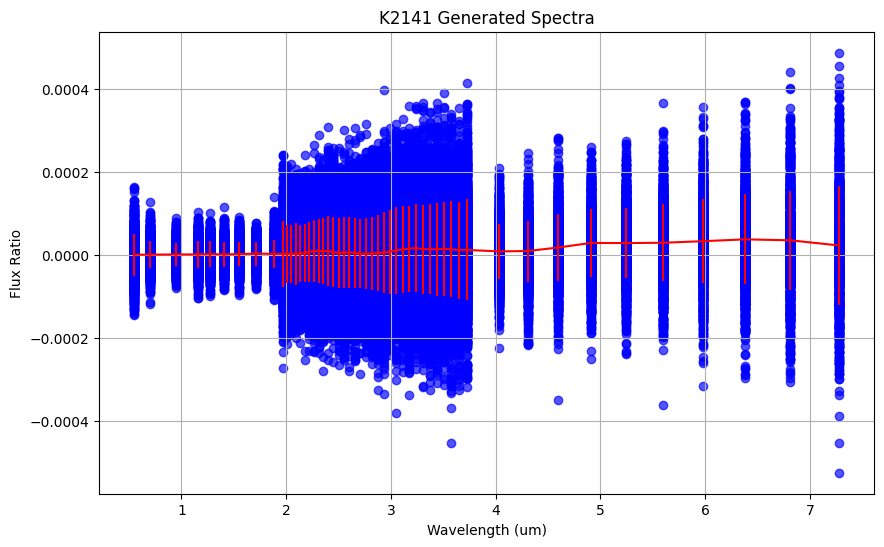

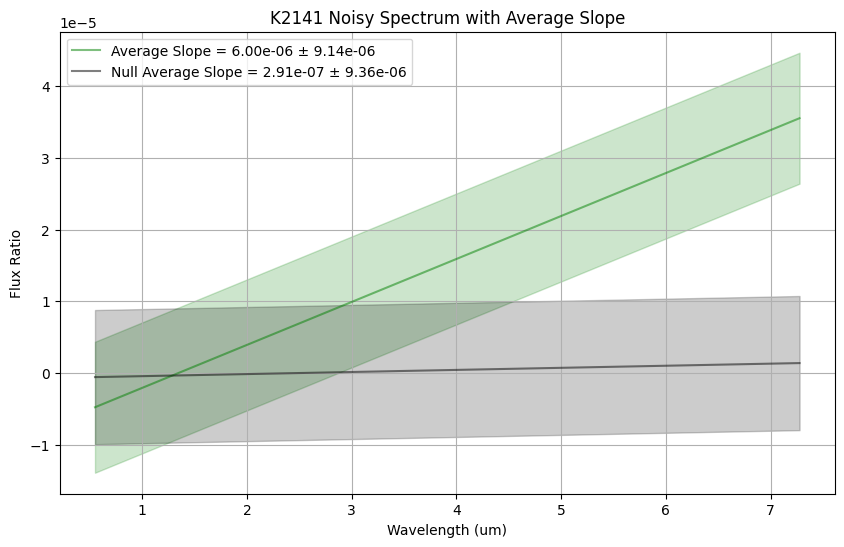

The measured slope is 0.61σ away from zero


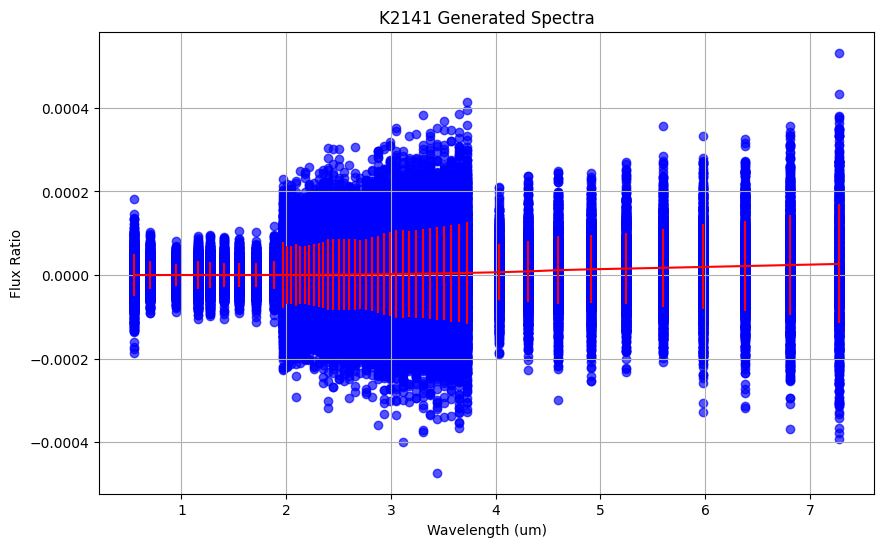

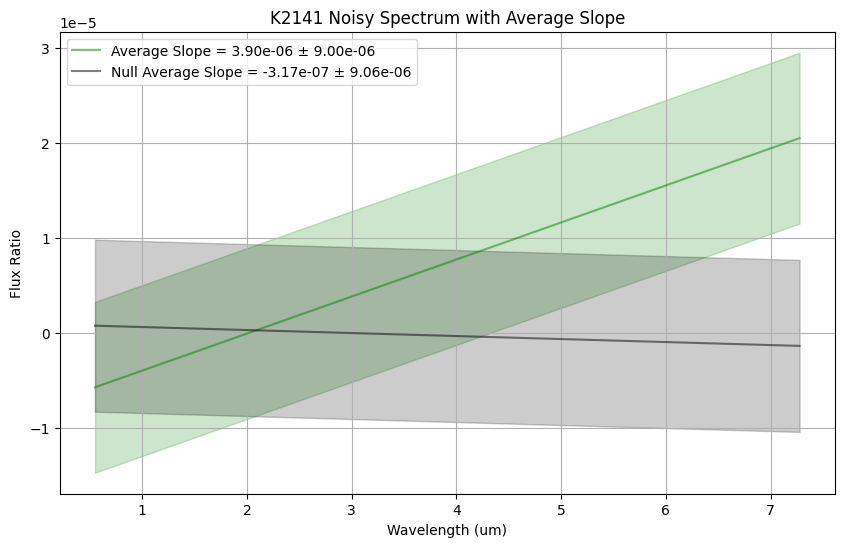

The measured slope is 0.47σ away from zero


In [9]:
# Generate spectra with TauREx
for folder in os.listdir(f"PLANETS/{name}/"):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue

    #set-up directories and paths
    outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
    planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"
    
    temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    atm_file = None
    for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break

    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    # check that the sum of all vmr is less or equal to 1
    total_vmr = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
    if total_vmr > 1:
        #renormalize the vmr values
        H2O_x = H2O_x / total_vmr
        CO2_x = CO2_x / total_vmr
        CH4_x = CH4_x / total_vmr
        CO_x = CO_x / total_vmr
        NH3_x = NH3_x / total_vmr
        N2_x = N2_x / total_vmr
        SO2_x = SO2_x / total_vmr
        S2_x = S2_x / total_vmr
        O2_x = O2_x / total_vmr
        H2_x = H2_x / total_vmr
        H2S_x = H2S_x / total_vmr

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    #convert to jupiter masses
    mass = mass / 317.8
    #set-up planet in Jupiter masses and radii
    planet = Planet(planet_mass=mass, planet_radius= radius, planet_distance=distance)

    star = PhoenixStar(temperature=temperature, radius=star_rad, metallicity=metallicity, phoenix_path='Phoenix/')

    #build emission model at the terminator
    em_terminator = EmissionModel( 
    planet=planet,
    temperature_profile=temp_profile_terminator,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em_terminator.add_contribution(AbsorptionContribution())
    em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em_terminator.add_contribution(RayleighContribution())

    em_terminator.build()

    #wavenumber grid, flux ratio, and transit depth
    wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

    wlgrid_t = 10000/wngrid_t[::-1]
    fpfs_t = fpfs_t[::-1]

    #read-in Ariel noise model
    #check if file exists
    
    if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
        file = f"ARIEL/arielrad_{name}/tier2.csv"

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional
    # instantiate flux binner with Ariel's wavelength binning
    fb = FluxBinner(wl, wb)
    output_t = fb.bindown(wlgrid_t, fpfs_t)
    wl, val, err, *_ = output_t

    #Binning
    if binning:
        wl = []; val = []; err = []

        results_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, obs, name, *new_points)
        new_points_t = make_next_level_points(results_t)

        results_level2_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, obs, name, *new_points_t)
        
        for out in results_level2_t:
            wl = np.append(wl, out[2])
            val = np.append(val, out[3])
            err = np.append(err, out[4])

        noise = err

    #Data generation
    # For every point in the spectrum, generate N points with a WGN distribution with mean equal to the planet flux and std equal to the noise.

    val_gen = np.zeros((N, len(wl)))
    for i in range(len(wl)):
        val_gen[:,i] = np.random.normal(val[i], noise[i] / np.sqrt(obs) * sigma, N)
    
    # null set
    null_gen = np.zeros((N, len(wl)))
    for i in range(len(wl)):
        null_gen[:,i] = np.random.normal(0, noise[i] / np.sqrt(obs) * sigma, N)

    # Fit a straight line to each generated spectrum and extract the slope and its uncertainty
    slopes = np.zeros(N); offsets = np.zeros(N)
    for i in range(N):
        coeffs = np.polyfit(wl, val_gen[i,:], 1) #returns coefficients
        slopes[i] = coeffs[0]
        offsets [i] = coeffs[1]
    # find the average slope and its uncertainty
    slope_avg = np.mean(slopes)
    offset_avg = np.mean(offsets)
    slope_std = np.std(slopes)

    #null slopes
    null_slopes = np.zeros(N); null_offsets = np.zeros(N)
    for i in range(N):
        coeffs = np.polyfit(wl, null_gen[i,:], 1) #returns coefficients
        null_slopes[i] = coeffs[0]
        null_offsets [i] = coeffs[1]
    # find the average null slope and its uncertainty
    null_slope_avg = np.mean(null_slopes)
    null_offset_avg = np.mean(null_offsets)
    null_slope_std = np.std(null_slopes)


    #fit line
    y_line = slope_avg * wl + offset_avg
    #fit null line
    null_line = null_slope_avg * wl + null_offset_avg
    

    fig = plt.figure(figsize=(10, 6))
    #plot of half of the generated spectra with error bars
    for i in range(N):
        plt.scatter(wl, val_gen[i,:], color='blue', alpha = 0.67)
    
    #plot of the original spectrum points with error bars
    plt.errorbar(wl, val, yerr=noise/np.sqrt(obs) * sigma, color='red', label='Original Spectrum', alpha = 1)
    
    plt.xlabel('Wavelength (um)')
    plt.ylabel('Flux Ratio')
    plt.title(f'{name} Generated Spectra')
    #plt.legend()
    plt.grid()
    show()

    fig = plt.figure(figsize=(10, 6))

    #plot the average slope line
    plt.plot(wl, y_line, color='green', label=f'Average Slope = {slope_avg:.2e} ± {slope_std:.2e}', alpha = 0.5)
    #1-sigma error region
    plt.fill_between(wl, y_line + slope_std, y_line - slope_std, color='green', alpha=0.2)

    #plot the null slope line
    plt.plot(wl, null_line, color='black', label=f'Null Average Slope = {null_slope_avg:.2e} ± {null_slope_std:.2e}', alpha = 0.5)
    #1-sigma error region
    plt.fill_between(wl, null_line + null_slope_std, null_line - null_slope_std, color='black', alpha=0.2)

    plt.xlabel('Wavelength (um)')
    plt.ylabel('Flux Ratio')
    plt.title(f'{name} Noisy Spectrum with Average Slope')
    plt.legend()
    plt.grid()
    show()

    #perform Z-test
    Z_score = (slope_avg - null_slope_avg) / null_slope_std
    print(fr"The measured slope is {Z_score:.2f}σ away from zero")
    